<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista-2-PJ0506/blob/main/UczenieMaszynowe_25_26_Lista2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analiza Zbiorów Danych
Laboratorium polega na analizie eksploracynej oraz wykonaniu redukcji wymiarowości dwóch zbiorów danych. W trakcie ćwiczenia zbadasz wskazane zbiory danych w następujących zadaniach:

1. Dla obu zbiorów danych:
    * Wczytaj zbiór danych. Opisz poszczególne kolumny - jakie zawierają atrybuty, co opisują. Zdecyduj czy któreś z kolumn należy przekształcić.
    * Zweryfikuj, czy w zbiorze występują wartości brakujące i/lub odstające. Zdecyduj jak (i czy) należy je usunąć.
    * Zbadaj korelacje między zmiennymi. Możesz posłużyć się macierzą korelacji.
    * Zwizualizuj najciekawsze/najważniejsze według Ciebie zależności w zbiorze.
2. Tylko dla zbioru Spotify Tracks:
    * Utwórz nową cechę "emocja" na podstawie dostępnych kolumn.
    * Dokonaj redukcji wymiarowości za pomocą metod *filter* oraz *wrapper*.
    * Zwizualizij zbiór za pomocą PCA oraz t-SNE. Sprawdź, jak na wizualizację wpływa normalizacja oraz standaryzacja danych.


## Zaliczenie laboratorium


 Za zadania można uzyskać maksymalnie 10 punktów według poniższej tabeli:

| ID | Zadanie | Zbiór danych | Ilość punktów |
|----|---------|--------------|---------------|
| 1  |Wczytanie zbioru danych. Określenie typów zmiennych. Opis kolumn. | Titanic, Spotify | 1 pkt |
| 2  |Filtracja danych. Usunięcie brakujących wartości. | Titanic, Spotify | 2 pkt|
| 3  |Analiza korelacji między zmiennymi (korzystając m. in. z macierzy korelacji) | Titanic, Spotify | 2 pkt |
| 4  |Przedstawienie wizualizacji (histogramów, pudełkowych) opisujących dane. | Titanic, Spotify | 2 pkt |
| 5  |Inżynieria i redukcja cech. | Spotify |1 pkt|
| 6 | Wizualizacja zbioru przy redukcji wymiarów poprzez PCA / t-SNE. Analiza wyników. | Spotify | 2 pkt. |

Analizę (punkty 1-4) należy przeprowadzić dla obu zbiorów. Redukcja (5-6) powinna zostać wykonana tylko dla zbioru *Spotify Tracks*.

### Pytania pomocnicze:
- Co decyduje o jakości i trudności zbioru danych? Czy któryś ze zbiorów z ćwiczenia jest łatwiejszy/trudniejszy? Dlaczego?
- Jakie informacje daje nam analiza pojedynczych cech w przeciwieństwie do analizy wielowymiarowej?
- Jakie własności zbioru mogą stanowić problem dla analizy?
- Na czym polega detekcja wartości odstających? Jaki wpływ na wyniki ma wybrana metoda?
- Jakie są wady/zalety metod radzenia sobie z brakującymi wartościami?
- Jak działa PCA i kiedy warto go stosować?
- Jak działa t-SNE i kiedy warto go stosować? Jaka jest fundamentalna różnica względem PCA?
- Na czym polega standaryzacja danych oraz normalizacja danych? Jakie są różnice
pomiędzy tymi metodami?

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Analiza zbioru danych [*Titanic*](https://www.kaggle.com/competitions/titanic/overview)

10 kwietnia 1912 roku brytyjski transatlantyk Titanic wypływa z Southampton, a 5 dni później schodzi na dno Atlantyku. Z 2208 osób na pokładzie, ocalało jedynie 704 [[1](https://pl.wikipedia.org/wiki/RMS_Titanic#Liczba_ofiar)]. Szanse przeżycia były silnie uzależnione od płci czy klasy podróży.

Zbiór danych Titanic zawiera informacje o 891 pasażerach statku. Podaje on między innymi płeć, klasę podróży, czy numer biletu. Celem tej części listy jest przeanalizowanie zbioru, opisanie wartości w nim występujących, i odpowiedź na pytanie: kto miał największe szanse na przeżycie Titanica?

## Opis danych

In [24]:
# wczytanie zbioru danych
titanic = pd.read_csv("/content/train.csv")

titanic.shape

(891, 12)

In [12]:
print(titanic)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [13]:
print("OPIS DANYCH")
print("PassengerId - numer biletu")
print("Survived - czy przeżył")
print("Pclass - klasa podróżowania")
print("Name - imię i nazwisko")
print("Sex - płeć")
print("Age - wiek")
print("SibSp - ilość rodzeństwa/małżonków na pokładzie")
print("Parch - ilość rodziców/dzieci na pokładzie")
print("Ticket - numer biletu")
print("Fare - cena biletu")
print("Cabin - numer kabiny")
print("Embarked - port zaokrętowania")

OPIS DANYCH
PassengerId - numer biletu
Survived - czy przeżył
Pclass - klasa podróżowania
Name - imię i nazwisko
Sex - płeć
Age - wiek
SibSp - ilość rodzeństwa/małżonków na pokładzie
Parch - ilość rodziców/dzieci na pokładzie
Ticket - numer biletu
Fare - cena biletu
Cabin - numer kabiny
Embarked - port zaokrętowania


## Przekształcenie danych

In [30]:
titanic['Sex_numeric'] = titanic['Sex'].map({'female': 1, 'male': 0})

## Brakujące wartości

Wskazówki:
- Wartości ciągłe możemy zinterpolować korzystając z gotowej metody [`pandas.DataFrame.interpolate`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html)
- Wartości dyskretne można uzupełnić konkretną wartością używając metody [`pandas.DataFrame.fillna`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html)
- Aby lepiej ocenić czym uzupełnić NaNy, warto wyświetlić kolumnę na wykresie.
- W przypadku dyskretnych wartości, warto również znaleźć wartości unikatowe funkcją `unique()`.

### Wiek pasażera

In [31]:
mediana_wieku = titanic['Age'].median()
titanic['Age'] = titanic['Age'].fillna(mediana_wieku)

In [32]:
assert titanic['Age'].isnull().values.any() == False, "Kolumna 'wiek' zawiera brakujące wartości"


### Zaokrętowanie

In [33]:
najczestszy_port = titanic['Embarked'].mode()[0]
titanic['Embarked'] = titanic['Embarked'].fillna(najczestszy_port)
#print(titanic)

In [34]:
assert titanic['Embarked'].isnull().values.any() == False, "Kolumna 'zaokrętowanie' zawiera brakujące wartości"

### Kabina

In [35]:
titanic['Cabin'] = titanic['Cabin'].str[0].fillna('U')
#print(titanic)

In [28]:
assert titanic['Cabin'].isnull().values.any() == False, "Kolumna 'kabina' zawiera brakujące wartości"

In [36]:
assert titanic.isnull().values.any() == False, "Zbiór danych zawiera brakujące wartości"

## Przedstawienie danych na wykresach

Wybierz 3-4 wykresy które przekazują według Ciebie najwięcej informacji.

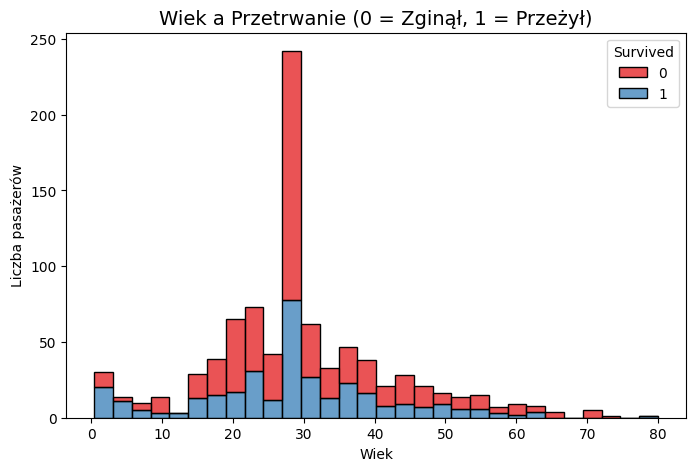

In [56]:
plt.figure(figsize=(8, 5))
sns.histplot(data=titanic, x='Age', hue='Survived', multiple='stack', palette='Set1')
plt.title('Wiek a Przetrwanie (0 = Zginął, 1 = Przeżył)', fontsize=14)
plt.xlabel('Wiek')
plt.ylabel('Liczba pasażerów')
plt.show()

/tmp/ipykernel_27811/251878614.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='Sex', y='Survived', palette='Set2', errorbar=None)


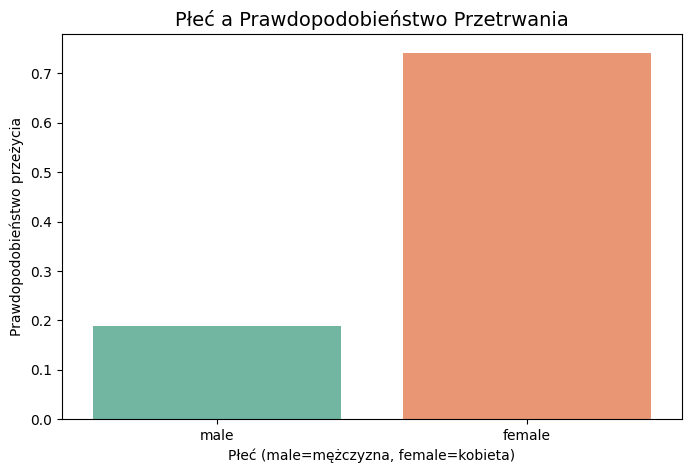

In [43]:
plt.figure(figsize=(8, 5))
sns.barplot(data=titanic, x='Sex', y='Survived', palette='Set2', errorbar=None)
plt.title('Płeć a Prawdopodobieństwo Przetrwania', fontsize=14)
plt.xlabel('Płeć (male=mężczyzna, female=kobieta)')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.show()

/tmp/ipykernel_27811/961078133.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='Pclass', y='Survived', palette='Set3', errorbar=None)


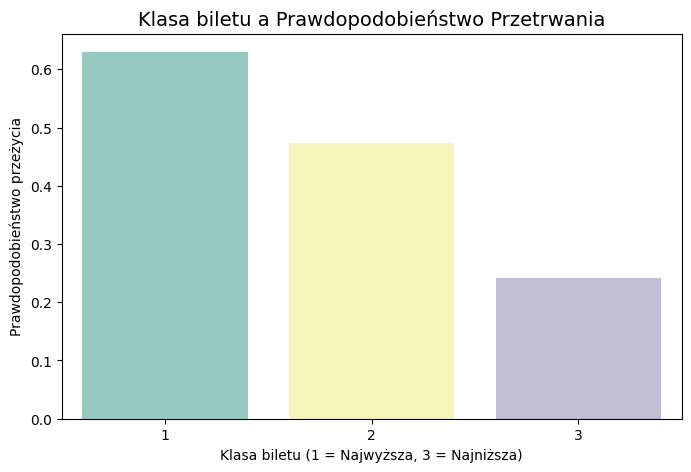

In [45]:
plt.figure(figsize=(8, 5))
sns.barplot(data=titanic, x='Pclass', y='Survived', palette='Set3', errorbar=None)
plt.title('Klasa biletu a Prawdopodobieństwo Przetrwania', fontsize=14)
plt.xlabel('Klasa biletu (1 = Najwyższa, 3 = Najniższa)')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.show()

Nie wykres, ale pokazuje wszystkie korelacje bądź ich brak więc uznałem że dodam.

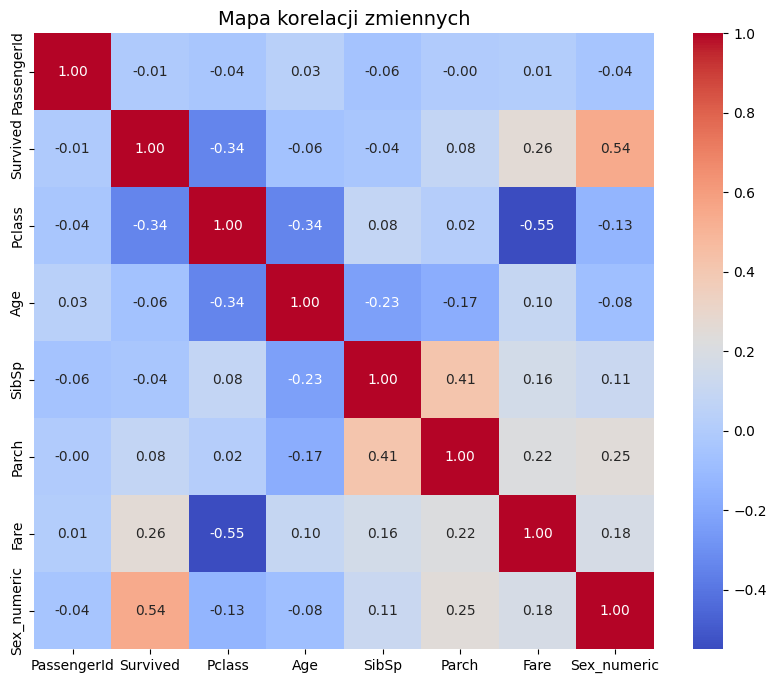

In [57]:
kolumny_numeryczne = titanic.select_dtypes(include=['int64', 'float64'])
korelacje = kolumny_numeryczne.corr()
plt.figure(figsize=(10, 8))

sns.heatmap(
    korelacje,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title('Mapa korelacji zmiennych', fontsize=14)
plt.show()

## Podsumowanie - ocena przeżywalności

Na podstawie informacji uzyskanych podczas ćwiczenia - kto miał największe szanse przeżyć Titanica? Jaka cecha (bądź zestaw cech) decydowały o wyniku podróży?

In [ ]:
# MIEJSCE NA TWÓJ KOD

najbardziej decydowała płeć (kobieta, bo ma wartość 1, dla męzczyzn wynosi -0.54 odwrotność tego), potem klasa jaką pasażer podróżował (na mapie korelacji jest wartość ujemna bo im wyższa liczba tym niższa klasa stąd jest odwrotność) oraz cena biletu (zasadniczo to jak bogaty ktoś był)

# Analiza zbioru danych [*Spotify Tracks*](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

Celem tej części listy jest analiza dużego, rzeczywistego zbioru danych zawierającego informacje o ponad 100 tysiącach piosenek ze Spotify. Zbiór zawiera kilkanaście cech numerycznych opisujących utwór oraz cechy kategoryczne: wykonawcę, nazwę albumu, gatunek.

Analiza zbioru pozwoli w późniejszym etapie na skuteczną redukcję wymiarowości za pomocą dwóch metod: *filter* oraz *wrapper*. Końcowym celem listy jest przedstawienie wielowymiarowego zbioru na dwuwymiarowym wykresie za pomocą `PCA` oraz `tSNE`.

## Opis danych

In [75]:
spotify = pd.read_csv("/content/dataset.csv")

spotify.shape

(114000, 21)

In [ ]:
print(spotify)

        Unnamed: 0                track_id                 artists  \
0                0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1                1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2                2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3                3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4                4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   
...            ...                     ...                     ...   
113995      113995  2C3TZjDRiAzdyViavDJ217           Rainy Lullaby   
113996      113996  1hIz5L4IB9hN3WRYPOCGPw           Rainy Lullaby   
113997      113997  6x8ZfSoqDjuNa5SVP5QjvX           Cesária Evora   
113998      113998  2e6sXL2bYv4bSz6VTdnfLs        Michael W. Smith   
113999      113999  2hETkH7cOfqmz3LqZDHZf5           Cesária Evora   

                                               album_name  \
0                                                  Comedy   
1                                    

In [ ]:
print("OPIS DANYCH")
print("Unnamed: 0 - błędna nazwa kolumny")
print("track_id - identyfikator utworu")
print("artists - wykonawca")
print("album_name - nazwa albumu")
print("track_name - nazwa utworu")
print("popularity - popularność utworu")
print("duration_ms - czas trwania utworu")
print("explicit - czy utwor zawiera eksplicitne słowo (przekleństwa nawiązania do sexu itp)")
print("danceability - jak bardzo utwór jest dostosowany do tańca")
print("energy - czy utwór jest energiczny")
print("key - tonacja utworu")
print("loudness - głośność w decybelach")
print("mode - w jakiej tonacji utrzymany jest utwór (major minor)")
print("speechiness - jak bardzo utwór jest mówiony")
print("acousticness - czy utwór jest akustyczny")
print("instrumentales - przewiduje czy utwór ma wokal (słowa mówione)")
print("liveness - czy utwór jest na żywo")
print("valence - czy utwór jest pozytywny")
print("tempo - tempo w BPM (bits per minute)")
print("time_signature - szacowane/określone metrum. Metrum (takt) to konwencja notacyjna określająca, ile beatów (uderzeń) przypada na każdy takt (lub miarę)")


OPIS DANYCH
Unnamed: 0 - błędna nazwa kolumny
track_id - identyfikator utworu
artists - wykonawca
album_name - nazwa albumu
track_name - nazwa utworu
popularity - popularność utworu
duration_ms - czas trwania utworu
explicit - czy utwor zawiera eksplicitne słowo (przekleństwa nawiązania do sexu itp)
danceability - jak bardzo utwór jest dostosowany do tańca
energy - czy utwór jest energiczny
key - tonacja utworu
loudness - głośność w decybelach
mode - w jakiej tonacji utrzymany jest utwór
speechiness - jak bardzo utwór jest mówiony
acousticness - czy utwór jest akustyczny
instrumentales - przewiduje czy utwór ma wokal (słowa mówione)
liveness - czy utwór jest na żywo
valence - czy utwór jest pozytywny
tempo - tempo w BPM (bits per minute)
time_signature - szacowane/określone metrum. Metrum (takt) to konwencja notacyjna określająca, ile beatów (uderzeń) przypada na każdy takt (lub miarę)


## Przekształcenia i filtracja danych

In [76]:
spotify = spotify.drop('Unnamed: 0', axis=1)
spotify = spotify.dropna()
spotify['explicit'] = spotify['explicit'].astype(int)

## Wizualizacje

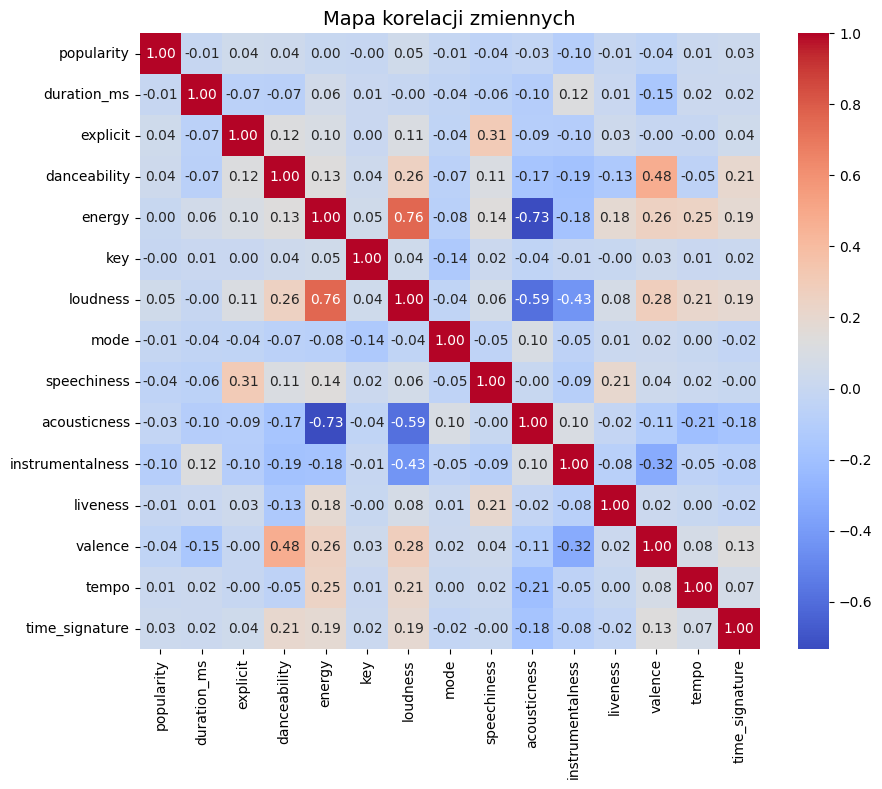

In [61]:
kolumny_numeryczne = spotify.select_dtypes(include=['int64', 'float64'])
korelacje = kolumny_numeryczne.corr()
plt.figure(figsize=(10, 8))

sns.heatmap(
    korelacje,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title('Mapa korelacji zmiennych', fontsize=14)
plt.show()

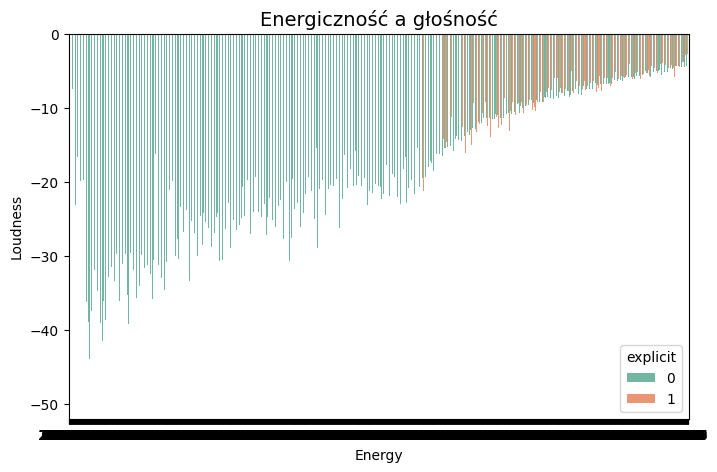

In [71]:
plt.figure(figsize=(8, 5))
sns.barplot(data=spotify, x='energy', y='loudness',hue='explicit', palette='Set2', errorbar=None)
plt.title('Energiczność a głośność', fontsize=14)
plt.xlabel('Energy')
plt.ylabel('Loudness')
plt.show()

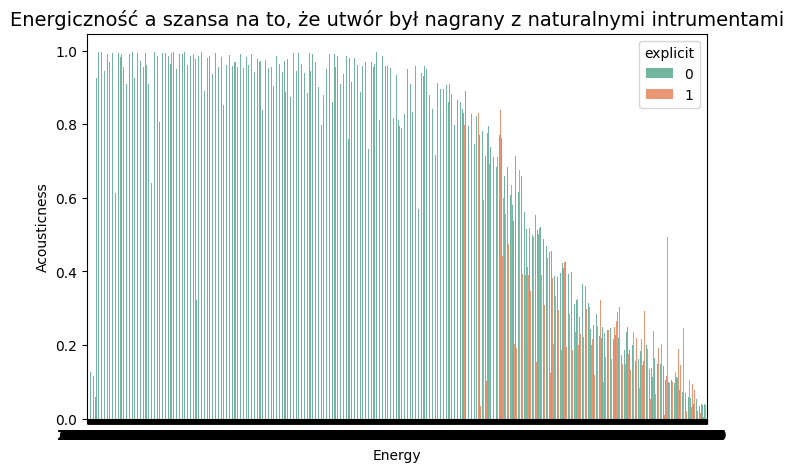

In [72]:
plt.figure(figsize=(8, 5))
sns.barplot(data=spotify, x='energy', y='acousticness',hue='explicit', palette='Set2', errorbar=None)
plt.title('Energiczność a szansa na to, że utwór był nagrany z naturalnymi intrumentami', fontsize=14)
plt.xlabel('Energy')
plt.ylabel('Acousticness')
plt.show()

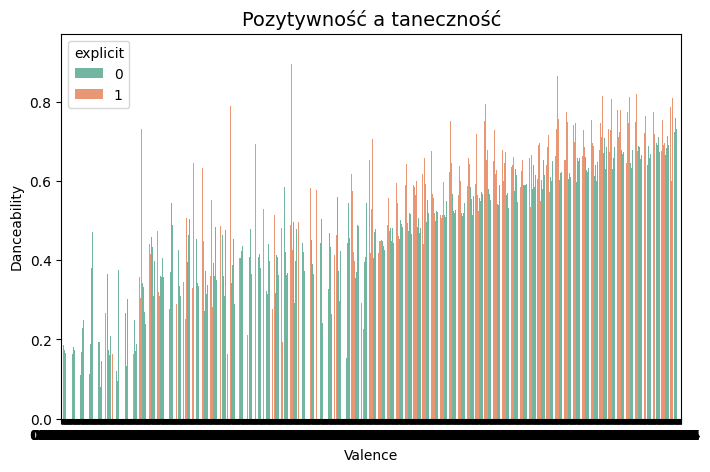

In [73]:
plt.figure(figsize=(8, 5))
sns.barplot(data=spotify, x='valence', y='danceability',hue='explicit', palette='Set2', errorbar=None)
plt.title('Pozytywność a taneczność', fontsize=14)
plt.xlabel('Valence')
plt.ylabel('Danceability')
plt.show()

## Dodanie nowej cechy - emocja

Emocje w muzyce są przekazywane za pomocą akordów. W zbiorze mamy dostępne informacje nt. klucza i mody piosenki. Ich kombinacja będzie odpowiadać emocji, zgodnie z [tą rozpiską](https://ledgernote.com/blog/interesting/musical-key-characteristics-emotions/).

Moda w zbiorze jest określona jako 0 lub 1, co odpowiada *minor* i odpowiednio *major*.

Klucz jest w [notacji liczbowej](https://en.wikipedia.org/wiki/Pitch_class), czyli 0 odpowiada **C**, 1 odpowiada **C#**, itd.

Twoim zadaniem jest dodanie nowej kolumny "emotion" na podstawie dostępnych informacji.

In [77]:
# dla ułatwienia - gotowe słowniki

key_map = {0: 'C', 1: 'C#', 2: 'D', 3: 'D#', 4: 'E', 5: 'F', 6: 'F#', 7: 'G', 8: 'G#', 9: 'A', 10: 'A#', 11: 'B'}

emotion_map = {
    ('C', 'Major'):  'Happy',
    ('C#', 'Major'): 'Joyful',
    ('D', 'Major'):  'Triumphant',
    ('D#', 'Major'): 'Cruel',
    ('E', 'Major'):  'Noisy',
    ('F', 'Major'):  'Passionate',
    ('F#', 'Major'): 'Bright',
    ('G', 'Major'):  'Rustic',
    ('G#', 'Major'): 'Rich',
    ('A', 'Major'):  'Pastoral',
    ('A#', 'Major'): 'Magnificent',
    ('B', 'Major'):  'Harsh',

    ('C', 'Minor'):  'Sad',
    ('C#', 'Minor'): 'Melancholic',
    ('D', 'Minor'):  'Pensive',
    ('D#', 'Minor'): 'Anxious',
    ('E', 'Minor'):  'Grieving',
    ('F', 'Minor'):  'Tragic',
    ('F#', 'Minor'): 'Gloomy',
    ('G', 'Minor'):  'Serious',
    ('G#', 'Minor'): 'Mournful',
    ('A', 'Minor'):  'Tender',
    ('A#', 'Minor'): 'Dark',
    ('B', 'Minor'):  'Lonely',
}

In [78]:
mapped_key = spotify['key'].map(key_map)
mapped_mode = spotify['mode'].map({0: 'Minor', 1: 'Major'})
polaczone_wartosci = list(zip(mapped_key, mapped_mode))
spotify['emotion'] = pd.Series(polaczone_wartosci).map(emotion_map)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


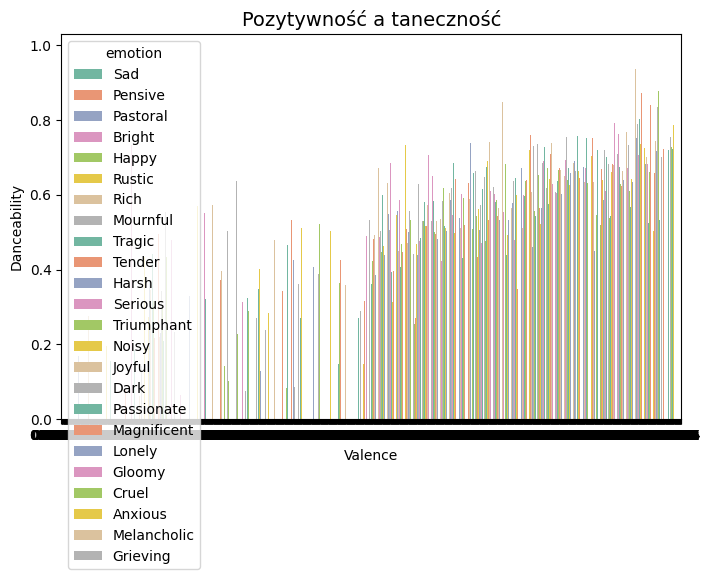

In [79]:
plt.figure(figsize=(8, 5))
sns.barplot(data=spotify, x='valence', y='danceability',hue='emotion', palette='Set2', errorbar=None)
plt.title('Pozytywność a taneczność', fontsize=14)
plt.xlabel('Valence')
plt.ylabel('Danceability')
plt.show()

to jest tylko do sprawdzenia czy istnieje emotion nie sensowny wykres

## Redukcja wymiarowości

W tej części zadania należy:
- zredukować wymiary zbioru poprzez usunięcie wybranych kolumn korzystając z metod *filter* i *wrapper*
- zwizualizować zbiór danych korzystając z metod redukcji wymiarowości
- zaimplementować standaryzację oraz normalizację
- przeanalizować jak te działania wpływają na wyniki redukcji



### Filter
Analizując pojedyncze kolumny, zdecyduj czy któreś z nich należy usunąć.

In [ ]:
# MIEJSCE NA TWÓJ KOD

### Wrapper
Korzystając z gotowej implementacji klasyfikatora las losowy, zdecyduj czy któreś z kolumn należy usunąć.

**UWAGA**

To jest bardzo uproszczona implementacja wrappera, która ma na celu jedynie pokazać jego działanie.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

def classify(df, features):
    """
    Dostępne cechy:
        'valence', 'year', 'acousticness', 'artists', 'danceability',
        'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key',
        'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date',
        'speechiness', 'tempo'
    """
    df = df.drop(columns=["Unnamed: 0", "track_id", "artists", "album_name", "track_name"], errors="ignore")
    df["explicit"] = df["explicit"].astype(int)
    df = df.sample(10000, random_state=42).dropna()

    df["popularity_bracket"] = pd.cut(df["popularity"], bins=[0, 33, 66, 100], labels=["low", "mid", "high"])
    df = df.dropna(subset=["popularity_bracket"])
    y = LabelEncoder().fit_transform(df["popularity_bracket"])
    X = df[features].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42))
    ])
    pipe.fit(X_train, y_train)

    acc  = pipe.score(X_test, y_test)

    print(f"Features  : {features}")
    print(f"Test Acc  : {acc:.4f}")
    return acc

In [ ]:
# WYWOŁAJ KLASYFIKATOR W TYM MIEJSCU
example_feats = ["duration_ms", "explicit", "danceability", "energy","key", "loudness", "mode", "speechiness", "acousticness","instrumentalness", "liveness", "valence", "tempo", "time_signature"]

base_acc = classify(spotify, example_feats)


### Wizualizacje (PCA i t-SNE)

W wizualizacji przetestuj kilka kolumn jako docelowe.

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn import preprocessing

In [ ]:
# przykładowe funkcje

def dataframe_xy(df):
    raise NotImplementedError()
    return X, y

# normalize to [0,1] range
def normalize(X):
    raise NotImplementedError()

# standarize (e.g, w/ scikit standard scaler)
def standarize(X):
    raise NotImplementedError()

# remove outliers
def remove_outliers(X, y):
    raise NotImplementedError()
